In [3]:
import pandas as pd
import numpy as np
import sqlite3
from openpyxl import Workbook

In [4]:
# Generate synthetic dataset for JIS University Agarpara students
np.random.seed(42)  # For reproducibility

# Number of students
num_students = 100

# Names (simplified)
first_names_boys = ['Rahul', 'Amit', 'Suresh', 'Raj', 'Vikram', 'Arjun', 'Karan', 'Rohit', 'Deepak', 'Manoj']
first_names_girls = ['Priya', 'Anjali', 'Kavita', 'Neha', 'Pooja', 'Riya', 'Sneha', 'Tina', 'Veena', 'Zara']
last_names = ['Sharma', 'Verma', 'Gupta', 'Singh', 'Kumar', 'Patel', 'Jain', 'Agarwal', 'Chopra', 'Mehta']

# Generate genders
genders = np.random.choice(['Boy', 'Girl'], num_students)

# Generate names based on gender
names = []
for gender in genders:
    if gender == 'Boy':
        first = np.random.choice(first_names_boys)
    else:
        first = np.random.choice(first_names_girls)
    last = np.random.choice(last_names)
    names.append(f"{first} {last}")

# Generate scores (out of 100, normal distribution)
scores = np.random.normal(75, 15, num_students).clip(0, 100).round(2)

# Create DataFrame
df = pd.DataFrame({
    'Name': names,
    'Gender': genders,
    'Score': scores
})

print("Dataset created:")
print(df.head())

Dataset created:
           Name Gender  Score
0    Amit Mehta    Boy  90.74
1  Anjali Mehta   Girl  94.88
2   Raj Agarwal    Boy  86.02
3  Karan Chopra    Boy  60.68
4   Rohit Kumar    Boy  63.73


In [10]:
# Save to Excel file
excel_file = 'jis_university_students.xlsx'
df.to_excel(excel_file, index=False)
print(f"Dataset saved to {excel_file}")

Dataset saved to jis_university_students.xlsx


In [11]:
# Analyze the data
# Who scored the most
highest_scorer = df.loc[df['Score'].idxmax()]
print(f"Highest Scorer: {highest_scorer['Name']} ({highest_scorer['Gender']}) with score {highest_scorer['Score']}")

# Mean and Median
mean_score = df['Score'].mean()
median_score = df['Score'].median()
print(f"Mean Score: {mean_score:.2f}")
print(f"Median Score: {median_score:.2f}")

# Mean and Median by Gender
mean_by_gender = df.groupby('Gender')['Score'].mean()
median_by_gender = df.groupby('Gender')['Score'].median()
print("\nMean by Gender:")
print(mean_by_gender)
print("\nMedian by Gender:")
print(median_by_gender)

Highest Scorer: Veena Agarwal (Girl) with score 100.0
Mean Score: 77.53
Median Score: 77.34

Mean by Gender:
Gender
Boy     76.466364
Girl    78.361964
Name: Score, dtype: float64

Median by Gender:
Gender
Boy     75.985
Girl    80.065
Name: Score, dtype: float64


In [12]:
# Create SQLite database
db_file = 'jis_university.db'
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

# Create table
cursor.execute('''
CREATE TABLE IF NOT EXISTS students (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    gender TEXT,
    score REAL
)
''')

# Insert data
for _, row in df.iterrows():
    cursor.execute('''
    INSERT INTO students (name, gender, score) VALUES (?, ?, ?)
    ''', (row['Name'], row['Gender'], row['Score']))

conn.commit()
print(f"Data inserted into database: {db_file}")

Data inserted into database: jis_university.db


In [13]:
# Query the database
# Highest scorer
cursor.execute('SELECT name, gender, score FROM students ORDER BY score DESC LIMIT 1')
highest = cursor.fetchone()
print(f"From DB - Highest Scorer: {highest[0]} ({highest[1]}) with score {highest[2]}")

# Mean and Median
cursor.execute('SELECT AVG(score), (SELECT score FROM students ORDER BY score LIMIT 1 OFFSET (SELECT COUNT(*) FROM students) / 2) AS median FROM students')
result = cursor.fetchone()
print(f"From DB - Mean Score: {result[0]:.2f}")
print(f"From DB - Median Score: {result[1]:.2f}")

# Mean by gender
cursor.execute('SELECT gender, AVG(score) FROM students GROUP BY gender')
means = cursor.fetchall()
print("\nFrom DB - Mean by Gender:")
for gender, mean in means:
    print(f"{gender}: {mean:.2f}")

conn.close()

From DB - Highest Scorer: Veena Agarwal (Girl) with score 100.0
From DB - Mean Score: 77.53
From DB - Median Score: 77.48

From DB - Mean by Gender:
Boy: 76.47
Girl: 78.36


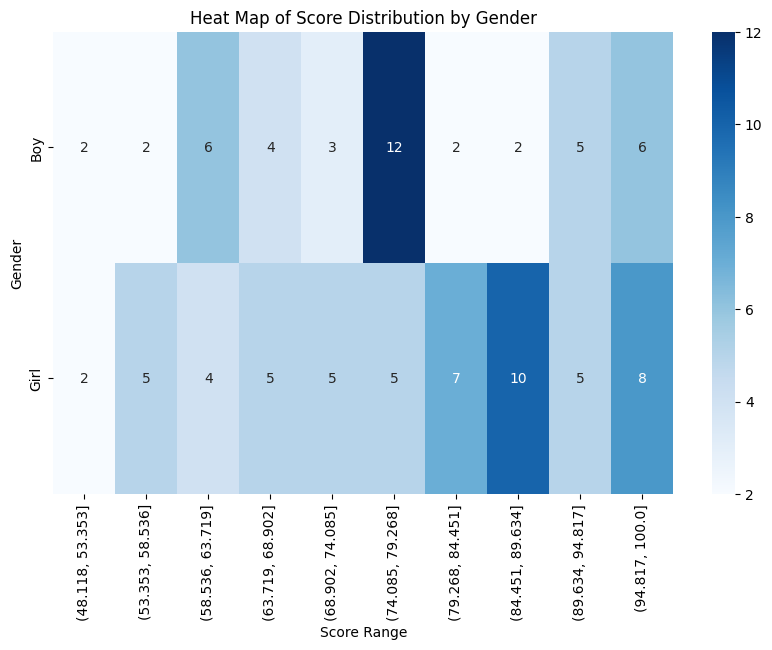

In [9]:
# Generate a heat map differentiating boys and girls
import seaborn as sns
import matplotlib.pyplot as plt

# Create bins for scores
df['Score_Bin'] = pd.cut(df['Score'], bins=10)

# Create a pivot table for heat map
pivot = pd.crosstab(df['Gender'], df['Score_Bin'])

# Plot heat map
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='Blues', fmt='d')
plt.title('Heat Map of Score Distribution by Gender')
plt.xlabel('Score Range')
plt.ylabel('Gender')
plt.show()